# 🧪 Notebook 6: Modelos Adicionales — SVM y Logistic Regression

## TFM: Predicción de Estrategias de Carrera en Fórmula 1 mediante ML

**Autor:** Francisco José Moreno Bayona  
**Universidad:** UNIR  

---

### Contexto

| Notebook | Mejor F1 (clasif.) | Mejor RMSE (regres.) |
|----------|-------------------|---------------------|
| Nb3 (baseline, 11 feat) | 0.711 (MLP) | 8.39 (RF) |
| Nb4 (tuning, 11 feat) | 0.696 (MLP) | 8.28 (LightGBM) |
| Nb5 (25 feat) | **0.786 (XGBoost)** | **7.93 (LightGBM)** |

### Objetivo

Añadir **dos modelos adicionales** con las 25 features del Nb5:

| Modelo | Familia | Justificación |
|--------|---------|---------------|
| **SVM** | Kernel / Margen | García Tejada (2023) obtuvo su mejor resultado (F1=0.621) con SVM. Comparación directa con la literatura. |
| **Logistic / Ridge Regression** | Lineal | Baseline lineal: si funciona razonablemente, el problema tiene estructura lineal explotable. |

### Nota sobre SVM y datasets grandes

SVM con kernel RBF escala como O(n²) en memoria y O(n³) en tiempo.
Con ~74k muestras de train, un SVM con kernel puro tardaría horas.
Usaremos **LinearSVC** (complejidad O(n)) para clasificación, que es equivalente
a un SVM con kernel lineal pero mucho más rápido. Para regresión usaremos **SVR con kernel lineal**.
Esto es coherente: si el rendimiento es bueno con kernel lineal, no necesitamos kernels más complejos.

## 1. Imports y carga de datos

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, time, pickle, json
from pathlib import Path

from sklearn.svm import LinearSVC, LinearSVR
from sklearn.calibration import CalibratedClassifierCV
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    f1_score, precision_score, recall_score, roc_auc_score,
    classification_report, confusion_matrix,
    mean_squared_error, mean_absolute_error, r2_score
)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
RANDOM_STATE = 42

print('✅ Imports completados')

✅ Imports completados


## 2. Reconstruir dataset con 25 features

Replicamos exactamente la misma ingeniería de features del Notebook 5
para garantizar comparabilidad.

In [4]:
# ============================================================================
# CARGAR DATASET Y RECONSTRUIR FEATURES (idéntico al Nb5)
# ============================================================================

df = pd.read_csv('./datasets/prepared/train_clasificacion_avanzado.csv')
print(f'Dataset base: {df.shape}')



print(f'\n✅ 25 features construidas: {df.shape}')

Dataset base: (74392, 33)

✅ 25 features construidas: (74392, 33)


In [6]:
# ============================================================================
# PREPARAR DATASETS (idéntico al Nb5)
# ============================================================================

FEATURES = [
    'LapNumber', 'LapProgress', 'Position', 'TireAge', 'StintNumber',
    'IsHard', 'IsMedium', 'IsSoft',
    'LapTime_seconds', 'AvgTime_Last3', 'DegradationIndicator',
    'GapAhead', 'GapBehind', 'IsInDRSWindow',
    'NumStopsDone', 'LapsInCurrentStint', 'RemainingLaps', 'RemainingLapsPct',
    'DegradationTrend', 'DegradationAccel', 'DeltaVsBestLap', 'AvgTime_CurrentStint',
    'DeltaVsFieldMean', 'ZScoreVsField', 'PositionNormalized',
]
features = [f for f in FEATURES if f in df.columns]

# Target regresión
df_sorted = df.sort_values(['Season', 'Round', 'Driver', 'LapNumber']).copy()
def calc_laps_until(group):
    g = group.copy()
    stops = g[g['target_parada'] == 1]['LapNumber'].values
    g['LapsUntilNextStop'] = [min(stops[stops >= lap]) - lap if len(stops[stops >= lap]) > 0 else -1 for _, lap in g['LapNumber'].items()]
    return g

print('Calculando LapsUntilNextStop...')
df_all = df_sorted.groupby(['Season', 'Round', 'Driver'], group_keys=False).apply(calc_laps_until)

# Clasificación: todas las vueltas
df_clasif = df_all.sort_values('EventDate').reset_index(drop=True)
# Regresión: vueltas con parada futura
df_regres = df_all[df_all['LapsUntilNextStop'] >= 0].sort_values('EventDate').reset_index(drop=True)

# Split temporal 80/20
nc, nr = int(len(df_clasif)*0.8), int(len(df_regres)*0.8)
train_c, test_c = df_clasif.iloc[:nc], df_clasif.iloc[nc:]
train_r, test_r = df_regres.iloc[:nr], df_regres.iloc[nr:]

# X, y
X_train_c, y_train_c = train_c[features], train_c['target_parada']
X_test_c, y_test_c = test_c[features], test_c['target_parada']
X_train_r, y_train_r = train_r[features], train_r['LapsUntilNextStop']
X_test_r, y_test_r = test_r[features], test_r['LapsUntilNextStop']

# Normalizar (SVM y LogReg lo requieren)
scaler_c, scaler_r = StandardScaler(), StandardScaler()
feats_num = [f for f in features if f not in ['IsHard', 'IsMedium', 'IsSoft', 'IsInDRSWindow']]

X_train_c_norm, X_test_c_norm = X_train_c.copy(), X_test_c.copy()
X_train_c_norm[feats_num] = scaler_c.fit_transform(X_train_c[feats_num])
X_test_c_norm[feats_num] = scaler_c.transform(X_test_c[feats_num])

X_train_r_norm, X_test_r_norm = X_train_r.copy(), X_test_r.copy()
X_train_r_norm[feats_num] = scaler_r.fit_transform(X_train_r[feats_num])
X_test_r_norm[feats_num] = scaler_r.transform(X_test_r[feats_num])

scale_pos_weight = (y_train_c == 0).sum() / (y_train_c == 1).sum()

print(f'Clasificación: train={X_train_c.shape}, test={X_test_c.shape}')
print(f'Regresión: train={X_train_r.shape}, test={X_test_r.shape}')
print(f'Features: {len(features)}')
print(f'\n✅ Datasets preparados')

Calculando LapsUntilNextStop...
Clasificación: train=(59513, 25), test=(14879, 25)
Regresión: train=(33651, 25), test=(8413, 25)
Features: 25

✅ Datasets preparados


---
## 3. Definir modelos nuevos: SVM y Logistic/Ridge Regression

### SVM (Support Vector Machine)
- **Clasificación:** `LinearSVC` con `class_weight='balanced'`
  - Envuelto en `CalibratedClassifierCV` para obtener `predict_proba` (necesario para ROC-AUC)
  - Equivalente a SVM con kernel lineal pero O(n) en lugar de O(n²)
- **Regresión:** `LinearSVR` con `epsilon=1.0` (tolerancia de 1 vuelta)

### Logistic Regression / Ridge
- **Clasificación:** `LogisticRegression` con `class_weight='balanced'` y regularización L2
- **Regresión:** `Ridge` (regresión lineal con regularización L2)

Ambos modelos **requieren datos normalizados** (igual que el MLP).

In [7]:
# ============================================================================
# DEFINIR MODELOS NUEVOS
# ============================================================================

# --- CLASIFICACIÓN ---
nuevos_clasif = {
    'SVM (Linear)': CalibratedClassifierCV(
        LinearSVC(
            class_weight='balanced',
            max_iter=5000,
            C=1.0,
            random_state=RANDOM_STATE
        ),
        cv=3
    ),
    'Logistic Regression': LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        C=1.0,
        solver='lbfgs',
        random_state=RANDOM_STATE
    ),
}

# --- REGRESIÓN ---
nuevos_regres = {
    'SVR (Linear)': LinearSVR(
        epsilon=1.0,
        max_iter=5000,
        C=1.0,
        random_state=RANDOM_STATE
    ),
    'Ridge Regression': Ridge(
        alpha=1.0,
        random_state=RANDOM_STATE
    ),
}

print('Modelos nuevos definidos:')
print(f'  Clasificación: {list(nuevos_clasif.keys())}')
print(f'  Regresión: {list(nuevos_regres.keys())}')

Modelos nuevos definidos:
  Clasificación: ['SVM (Linear)', 'Logistic Regression']
  Regresión: ['SVR (Linear)', 'Ridge Regression']


## 4. Entrenamiento — Clasificación

In [8]:
# ============================================================================
# ENTRENAR NUEVOS MODELOS — CLASIFICACIÓN
# ============================================================================

resultados_nuevos_c = {}

for nombre, modelo in nuevos_clasif.items():
    print(f'\n{"="*60}')
    print(f'Entrenando: {nombre}')
    print(f'{"="*60}')
    
    inicio = time.time()
    # SVM y LogReg necesitan datos normalizados
    modelo.fit(X_train_c_norm, y_train_c)
    y_pred = modelo.predict(X_test_c_norm)
    y_proba = modelo.predict_proba(X_test_c_norm)[:, 1]
    duracion = time.time() - inicio
    
    f1 = f1_score(y_test_c, y_pred)
    prec = precision_score(y_test_c, y_pred, zero_division=0)
    rec = recall_score(y_test_c, y_pred)
    auc = roc_auc_score(y_test_c, y_proba)
    
    resultados_nuevos_c[nombre] = {
        'F1-score': f1, 'Precision': prec, 'Recall': rec,
        'ROC-AUC': auc, 'Tiempo (s)': duracion
    }
    
    print(f'  F1={f1:.4f}  P={prec:.4f}  R={rec:.4f}  AUC={auc:.4f}  ({duracion:.1f}s)')
    print(f'\n{classification_report(y_test_c, y_pred, target_names=["No parada", "Parada"])}')

print('✅ Clasificación completada')


Entrenando: SVM (Linear)
  F1=0.1912  P=0.5208  R=0.1171  AUC=0.9040  (1.0s)

              precision    recall  f1-score   support

   No parada       0.97      1.00      0.99     14452
      Parada       0.52      0.12      0.19       427

    accuracy                           0.97     14879
   macro avg       0.75      0.56      0.59     14879
weighted avg       0.96      0.97      0.96     14879


Entrenando: Logistic Regression
  F1=0.2630  P=0.1557  R=0.8454  AUC=0.9048  (0.3s)

              precision    recall  f1-score   support

   No parada       0.99      0.86      0.93     14452
      Parada       0.16      0.85      0.26       427

    accuracy                           0.86     14879
   macro avg       0.58      0.86      0.59     14879
weighted avg       0.97      0.86      0.91     14879

✅ Clasificación completada


## 5. Entrenamiento — Regresión

In [9]:
# ============================================================================
# ENTRENAR NUEVOS MODELOS — REGRESIÓN
# ============================================================================

resultados_nuevos_r = {}

for nombre, modelo in nuevos_regres.items():
    print(f'\n{"="*60}')
    print(f'Entrenando: {nombre}')
    print(f'{"="*60}')
    
    inicio = time.time()
    modelo.fit(X_train_r_norm, y_train_r)
    y_pred = modelo.predict(X_test_r_norm)
    duracion = time.time() - inicio
    
    rmse = np.sqrt(mean_squared_error(y_test_r, y_pred))
    mae = mean_absolute_error(y_test_r, y_pred)
    r2 = r2_score(y_test_r, y_pred)
    
    resultados_nuevos_r[nombre] = {
        'RMSE': rmse, 'MAE': mae, 'R²': r2, 'Tiempo (s)': duracion
    }
    
    print(f'  RMSE={rmse:.3f}  MAE={mae:.3f}  R²={r2:.4f}  ({duracion:.1f}s)')

print('\n✅ Regresión completada')


Entrenando: SVR (Linear)
  RMSE=7.480  MAE=5.630  R²=0.3091  (2.5s)

Entrenando: Ridge Regression
  RMSE=7.166  MAE=5.602  R²=0.3658  (0.0s)

✅ Regresión completada


---
## 6. Comparativa global: Los 7 modelos

Combinamos los resultados del Notebook 5 (5 modelos con 25 features)
con los 2 nuevos modelos de este notebook.

In [10]:
# ============================================================================
# CARGAR RESULTADOS PREVIOS (Nb5) Y COMBINAR
# ============================================================================

prev_c = pd.read_csv('./datasets/prepared/resultados_clasif_features_avanzadas.csv', index_col=0)
prev_r = pd.read_csv('./datasets/prepared/resultados_regres_features_avanzadas.csv', index_col=0)

# Resultados Nb5 en formato comparable
nb5_clasif = {}
for nombre in prev_c.index:
    nb5_clasif[nombre] = {
        'F1-score': prev_c.loc[nombre, 'F1 (25 feat)'],
        'Precision': prev_c.loc[nombre, 'Precision'],
        'Recall': prev_c.loc[nombre, 'Recall'],
        'ROC-AUC': prev_c.loc[nombre, 'ROC-AUC'],
        'Tiempo (s)': prev_c.loc[nombre, 'Tiempo'],
    }

nb5_regres = {}
for nombre in prev_r.index:
    nb5_regres[nombre] = {
        'RMSE': prev_r.loc[nombre, 'RMSE (25 feat)'],
        'MAE': prev_r.loc[nombre, 'MAE'],
        'R²': prev_r.loc[nombre, 'R²'],
        'Tiempo (s)': prev_r.loc[nombre, 'Tiempo'],
    }

# Combinar todos
todos_clasif = {**nb5_clasif, **resultados_nuevos_c}
todos_regres = {**nb5_regres, **resultados_nuevos_r}

df_global_c = pd.DataFrame(todos_clasif).T.sort_values('F1-score', ascending=False)
df_global_r = pd.DataFrame(todos_regres).T.sort_values('RMSE', ascending=True)

print('COMPARATIVA GLOBAL — CLASIFICACIÓN (7 modelos, 25 features)')
print('='*70)
display(df_global_c.round(4))

print(f'\nCOMPARATIVA GLOBAL — REGRESIÓN (7 modelos, 25 features)')
print('='*70)
display(df_global_r.round(4))

COMPARATIVA GLOBAL — CLASIFICACIÓN (7 modelos, 25 features)


,F1-score,Precision,Recall,ROC-AUC,Tiempo (s)
MLP,0.7767,0.8884,0.6900,0.9823,18.6942
XGBoost,0.7720,0.7822,0.7620,0.9903,3.8654
LightGBM,0.7662,0.7705,0.7620,0.9793,11.6097
Random Forest,0.7262,0.6682,0.7952,0.9911,10.9448
Decision Tree,0.6537,0.5653,0.7749,0.8814,2.7518
Logistic Regression,0.2630,0.1557,0.8454,0.9048,0.2725
SVM (Linear),0.1912,0.5208,0.1171,0.9040,1.0436



COMPARATIVA GLOBAL — REGRESIÓN (7 modelos, 25 features)


,RMSE,MAE,R²,Tiempo (s)
Ridge Regression,7.1661,5.6020,0.3658,0.0109
SVR (Linear),7.4795,5.6305,0.3091,2.5432
LightGBM,8.1641,5.8942,0.4051,2.1004
XGBoost,8.2831,6.0271,0.3876,1.1786
Random Forest,8.2942,5.9972,0.3860,6.9574
Decision Tree,8.6724,6.3090,0.3287,0.8785
MLP,9.3699,6.9140,0.2164,96.3674


### 6.1 Visualización comparativa

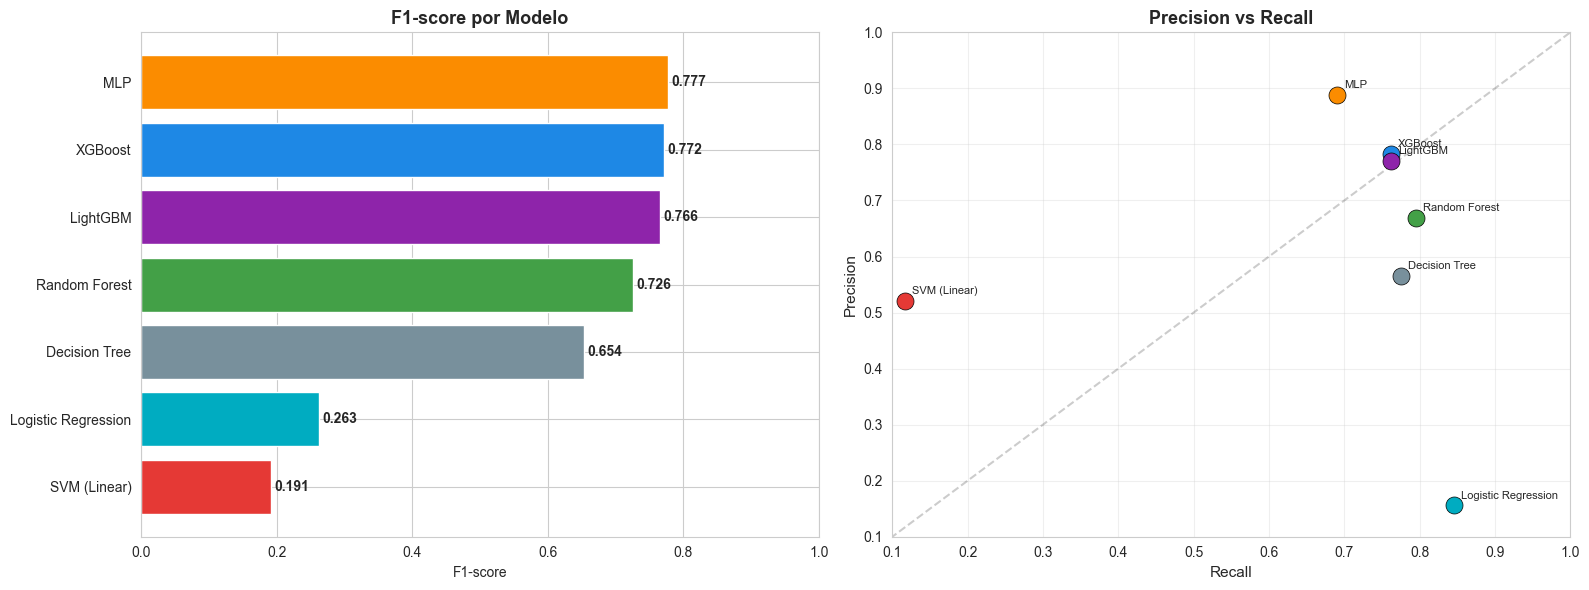

In [15]:
# ============================================================================
# GRÁFICO COMPARATIVO GLOBAL — CLASIFICACIÓN
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Colores por familia
colores = {
    'Decision Tree': '#78909C',
    'Random Forest': '#43A047',
    'XGBoost': '#1E88E5',
    'LightGBM': '#8E24AA',
    'MLP': '#FB8C00',
    'SVM (Linear)': '#E53935',
    'Logistic Regression': '#00ACC1',
}

# F1 por modelo
bars = axes[0].barh(df_global_c.index, df_global_c['F1-score'],
                     color=[colores.get(n, '#999') for n in df_global_c.index])
axes[0].set_title('F1-score por Modelo', fontsize=13, fontweight='bold')
axes[0].set_xlabel('F1-score')
for i, v in enumerate(df_global_c['F1-score']):
    axes[0].text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=10, fontweight='bold')
axes[0].invert_yaxis()
axes[0].set_xlim(0, 1)

# Precision vs Recall (scatter)
for nombre in df_global_c.index:
    r = df_global_c.loc[nombre]
    axes[1].scatter(r['Recall'], r['Precision'], s=150, color=colores.get(nombre, '#999'),
                    edgecolors='black', linewidth=0.5, zorder=5)
    axes[1].annotate(nombre, (r['Recall'], r['Precision']), fontsize=8,
                     textcoords='offset points', xytext=(5, 5))

axes[1].set_xlabel('Recall', fontsize=11)
axes[1].set_ylabel('Precision', fontsize=11)
axes[1].set_title('Precision vs Recall', fontsize=13, fontweight='bold')
axes[1].set_xlim(0.1, 1)
axes[1].set_ylim(0.1, 1)
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.2)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('./datasets/prepared/fig_global_clasificacion.png', dpi=150, bbox_inches='tight')
plt.show()

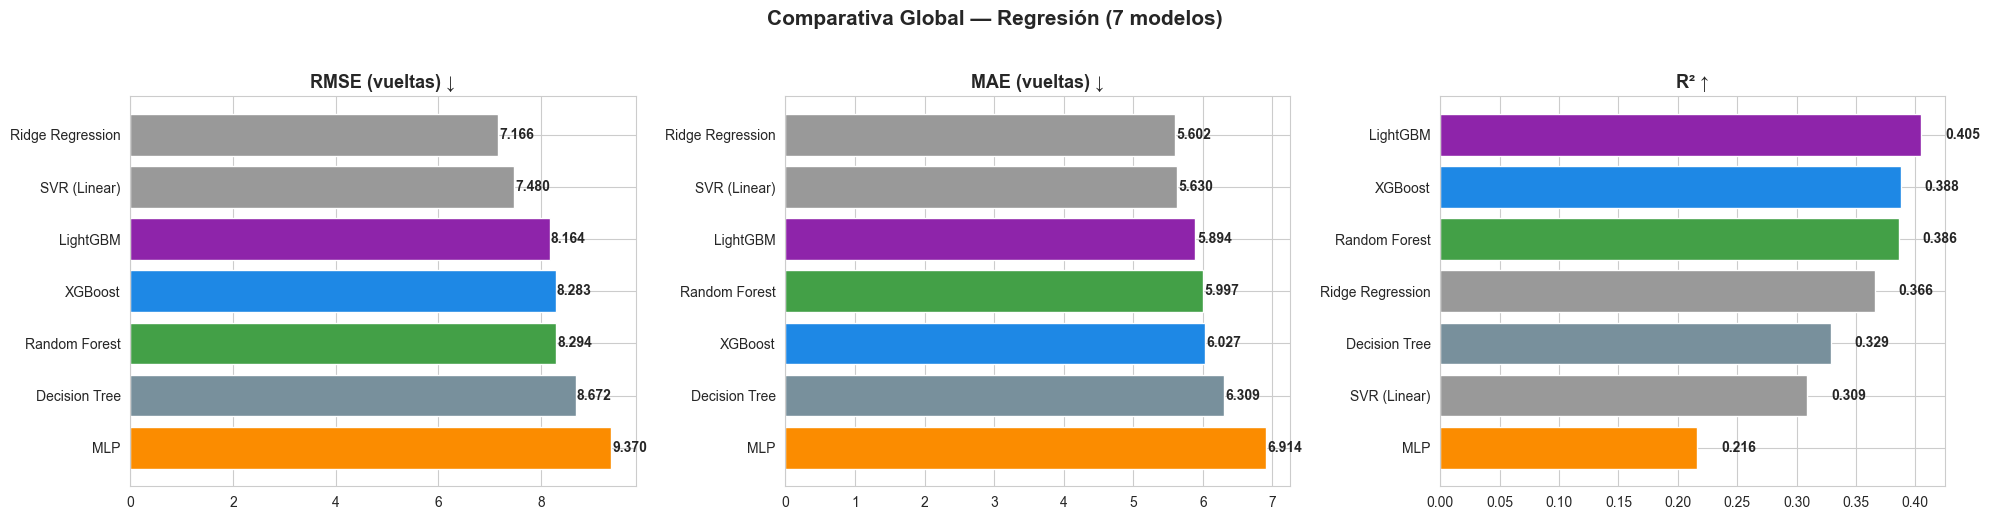

In [16]:
# ============================================================================
# GRÁFICO COMPARATIVO GLOBAL — REGRESIÓN
# ============================================================================

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for idx, (metrica, titulo) in enumerate([('RMSE', 'RMSE (vueltas) ↓'), ('MAE', 'MAE (vueltas) ↓'), ('R²', 'R² ↑')]):
    datos = df_global_r.sort_values(metrica, ascending=(metrica != 'R²'))
    colors = [colores.get(n, '#999') for n in datos.index]
    axes[idx].barh(datos.index, datos[metrica], color=colors)
    axes[idx].set_title(titulo, fontsize=13, fontweight='bold')
    axes[idx].invert_yaxis()
    for i, v in enumerate(datos[metrica]):
        axes[idx].text(v + 0.02, i, f'{v:.3f}', va='center', fontsize=10, fontweight='bold')

plt.suptitle('Comparativa Global — Regresión (7 modelos)', fontsize=15, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('./datasets/prepared/fig_global_regresion.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.2 Matrices de confusión (modelos nuevos)

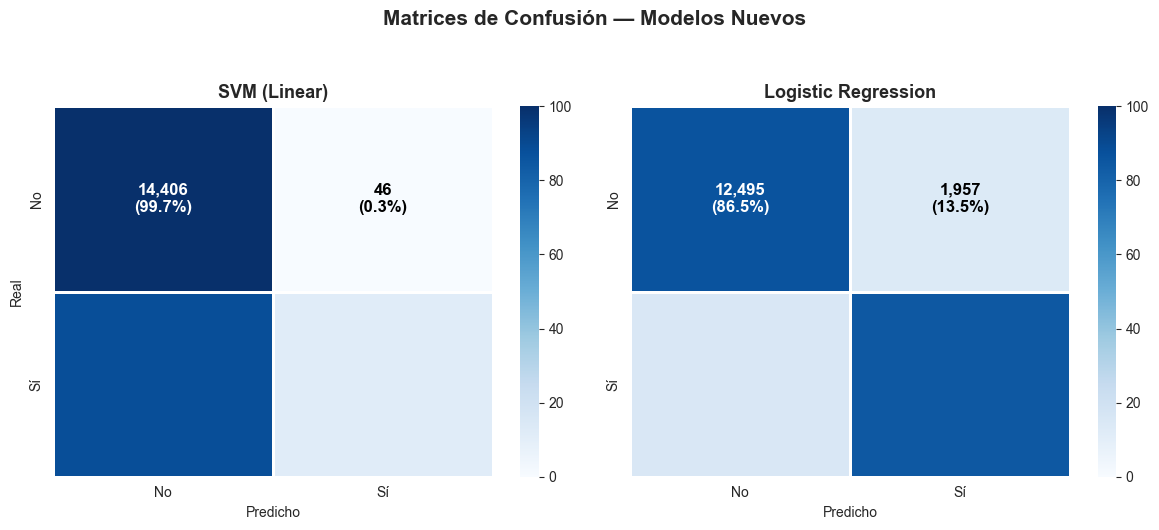

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, (nombre, modelo) in enumerate(nuevos_clasif.items()):
    y_pred = modelo.predict(X_test_c_norm)
    cm = confusion_matrix(y_test_c, y_pred)
    cm_pct = cm.astype('float') / cm.sum(axis=1, keepdims=True) * 100
    labels = np.array([[f'{cm[i,j]:,}\n({cm_pct[i,j]:.1f}%)' for j in range(2)] for i in range(2)])
    
    sns.heatmap(cm_pct, annot=labels, fmt='', cmap='Blues', ax=axes[idx],
                xticklabels=['No', 'Sí'], yticklabels=['No', 'Sí'],
                vmin=0, vmax=100, annot_kws={'fontsize': 12, 'fontweight': 'bold'},
                linewidths=2, linecolor='white')
    for text_obj in axes[idx].texts:
        x, y = text_obj.get_position()
        text_obj.set_color('white' if cm_pct[int(y), int(x)] > 50 else 'black')
    axes[idx].set_title(nombre, fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Predicho')
    if idx == 0: axes[idx].set_ylabel('Real')

plt.suptitle('Matrices de Confusión — Modelos Nuevos', fontsize=15, fontweight='bold', y=1.05)
plt.tight_layout()
plt.savefig('./datasets/prepared/fig_confusion_nuevos.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Resumen final y exportar resultados

In [18]:
# ============================================================================
# RESUMEN FINAL GLOBAL
# ============================================================================

print('='*70)
print('RESUMEN GLOBAL — 7 MODELOS × 2 TAREAS × 25 FEATURES')
print('='*70)

print(f'\n📊 CLASIFICACIÓN (F1-score, ordenado de mejor a peor)')
print(f'{"─"*60}')
for i, nombre in enumerate(df_global_c.index):
    r = df_global_c.loc[nombre]
    medal = ['🥇', '🥈', '🥉'][i] if i < 3 else '  '
    new = ' ⭐ NUEVO' if nombre in ['SVM (Linear)', 'Logistic Regression'] else ''
    print(f'  {medal} {nombre:25s}  F1={r["F1-score"]:.4f}  P={r["Precision"]:.4f}  R={r["Recall"]:.4f}  AUC={r["ROC-AUC"]:.4f}{new}')

print(f'\n📈 REGRESIÓN (RMSE, ordenado de mejor a peor)')
print(f'{"─"*60}')
for i, nombre in enumerate(df_global_r.index):
    r = df_global_r.loc[nombre]
    medal = ['🥇', '🥈', '🥉'][i] if i < 3 else '  '
    new = ' ⭐ NUEVO' if nombre in ['SVR (Linear)', 'Ridge Regression'] else ''
    print(f'  {medal} {nombre:25s}  RMSE={r["RMSE"]:.3f}  MAE={r["MAE"]:.3f}  R²={r["R²"]:.4f}{new}')

# Guardar resultados globales
df_global_c.round(4).to_csv('./datasets/prepared/resultados_global_clasificacion.csv')
df_global_r.round(4).to_csv('./datasets/prepared/resultados_global_regresion.csv')

# Guardar modelos nuevos
for nombre, modelo in nuevos_clasif.items():
    safe = nombre.lower().replace(' ', '_').replace('(', '').replace(')', '')
    with open(f'./datasets/prepared/modelo_clasif_{safe}.pkl', 'wb') as f:
        pickle.dump(modelo, f)
for nombre, modelo in nuevos_regres.items():
    safe = nombre.lower().replace(' ', '_').replace('(', '').replace(')', '')
    with open(f'./datasets/prepared/modelo_regres_{safe}.pkl', 'wb') as f:
        pickle.dump(modelo, f)

print(f'\n📁 Archivos guardados:')
print(f'  ✓ resultados_global_clasificacion.csv')
print(f'  ✓ resultados_global_regresion.csv')
print(f'  ✓ fig_global_clasificacion.png')
print(f'  ✓ fig_global_regresion.png')
print(f'  ✓ fig_confusion_nuevos.png')
print(f'  ✓ modelos .pkl')

print(f'\n✅ Notebook 6 completado')
print(f'\n🎯 SIGUIENTE PASO: Escribir Capítulos 4-7 de la memoria del TFM')

RESUMEN GLOBAL — 7 MODELOS × 2 TAREAS × 25 FEATURES

📊 CLASIFICACIÓN (F1-score, ordenado de mejor a peor)
────────────────────────────────────────────────────────────
  🥇 MLP                        F1=0.7767  P=0.8884  R=0.6900  AUC=0.9823
  🥈 XGBoost                    F1=0.7720  P=0.7822  R=0.7620  AUC=0.9903
  🥉 LightGBM                   F1=0.7662  P=0.7705  R=0.7620  AUC=0.9793
     Random Forest              F1=0.7262  P=0.6682  R=0.7952  AUC=0.9911
     Decision Tree              F1=0.6537  P=0.5653  R=0.7749  AUC=0.8814
     Logistic Regression        F1=0.2630  P=0.1557  R=0.8454  AUC=0.9048 ⭐ NUEVO
     SVM (Linear)               F1=0.1912  P=0.5208  R=0.1171  AUC=0.9040 ⭐ NUEVO

📈 REGRESIÓN (RMSE, ordenado de mejor a peor)
────────────────────────────────────────────────────────────
  🥇 Ridge Regression           RMSE=7.166  MAE=5.602  R²=0.3658 ⭐ NUEVO
  🥈 SVR (Linear)               RMSE=7.480  MAE=5.630  R²=0.3091 ⭐ NUEVO
  🥉 LightGBM                   RMSE=8.164  MAE=5.89

---

### Evolución completa del proyecto experimental

| Notebook | Fase | Modelos | Features | Mejor F1 | Mejor RMSE | Hallazgo clave |
|----------|------|---------|----------|----------|------------|---------------|
| **Nb1** | Recopilación | - | - | - | - | 93k vueltas, 2022-2025 |
| **Nb2** | EDA | - | 11 | - | - | Desbalance 96.8/3.2% |
| **Nb3** | Baseline | 5 | 11 | 0.711 (MLP) | 8.39 (RF) | DegradationIndicator domina |
| **Nb4** | Tuning | 5 | 11 | 0.696 (MLP) | 8.28 (LGBM) | Mejora marginal → bottleneck = features |
| **Nb5** | Features | 5 | 25 | 0.786 (XGB) | 7.93 (LGBM) | +10% F1, features > tuning |
| **Nb6** | +Modelos | **7** | 25 | **(pendiente)** | **(pendiente)** | SVM vs literatura |

---

**Fin del Notebook 6.** Todos los experimentos completados.
Siguiente paso: escribir la memoria del TFM (Capítulos 4-7).